In [1]:
import sys
import os

# add project root to python path
sys.path.append(os.path.abspath(".."))

In [2]:
import torch
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, TensorDataset

from src.models import TinyCNN
from src.client import Client
from src.server import Server
from src.reliability import ReliabilityTracker

In [3]:
def create_dummy_data(num_samples=500):
    x = torch.randn(num_samples, 1, 28, 28)
    y = torch.randint(0, 10, (num_samples,))
    return TensorDataset(x, y)

def split_data(dataset, num_clients=2):
    length = len(dataset) // num_clients
    return torch.utils.data.random_split(dataset, [length] * num_clients)

dataset = create_dummy_data()
client_datasets = split_data(dataset, num_clients=2)

print("Dataset Ready")

Dataset Ready


In [4]:
global_model = TinyCNN(num_classes=10)

tracker = ReliabilityTracker()
server = Server(global_model, reliability_tracker=tracker)

clients = []

for data in client_datasets:
    loader = DataLoader(data, batch_size=32, shuffle=True)

    model = TinyCNN(num_classes=10)
    model.load_state_dict(global_model.state_dict())

    clients.append(Client(model, loader))

print(f"Created {len(clients)} clients")

Created 2 clients


In [5]:
def evaluate(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            pred = out.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

    return correct / total

In [6]:
rounds = 5

loss_history = []
acc_history = []
reliability_history = []

for r in range(rounds):

    print(f"\n========== ROUND {r+1} ==========")

    round_loss = 0

    server.client_updates = []
    server.client_ids = []

    round_reliability = []

    for i, client in enumerate(clients):

        loss = client.train(epochs=1)

        score = tracker.compute_reliability(
            client_id=i,
            loss=loss
        )

        server.add_client_update(
            i,
            client.get_weights()
        )

        round_loss += loss
        round_reliability.append(score)

        print(
            f"Client {i}: "
            f"Loss={loss:.4f}, "
            f"Reliability={score:.4f}"
        )

    global_weights = server.aggregate()

    for client in clients:
        client.set_weights(global_weights)

    acc = evaluate(
        global_model,
        DataLoader(dataset, batch_size=32)
    )

    loss_history.append(round_loss)
    acc_history.append(acc)
    reliability_history.append(
        sum(round_reliability) / len(round_reliability)
    )

    print(f"Global Accuracy: {acc:.4f}")


========== ROUND 1 ==========
Client 0: Loss=2.3599, Reliability=0.6543
Client 1: Loss=2.3442, Reliability=0.6560
Global Accuracy: 0.1260

========== ROUND 2 ==========
Client 0: Loss=2.2871, Reliability=0.5240
Client 1: Loss=2.2943, Reliability=0.5239
Global Accuracy: 0.1180

========== ROUND 3 ==========
Client 0: Loss=2.2592, Reliability=0.5012
Client 1: Loss=2.2703, Reliability=0.5003
Global Accuracy: 0.1720

========== ROUND 4 ==========
Client 0: Loss=2.2412, Reliability=0.4916
Client 1: Loss=2.2466, Reliability=0.4911
Global Accuracy: 0.1840

========== ROUND 5 ==========
Client 0: Loss=2.2371, Reliability=0.4705
Client 1: Loss=2.2664, Reliability=0.4668
Global Accuracy: 0.1200


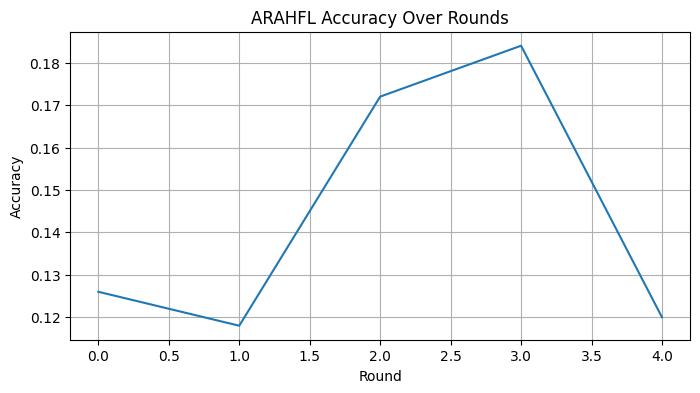

In [7]:
plt.figure(figsize=(8,4))
plt.plot(acc_history)
plt.title("ARAHFL Accuracy Over Rounds")
plt.xlabel("Round")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

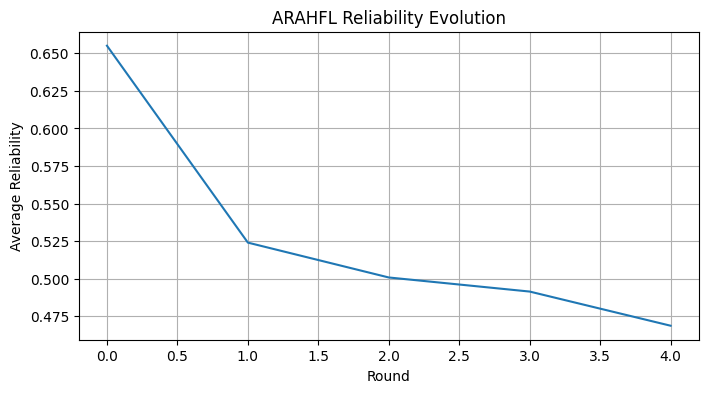

In [8]:
plt.figure(figsize=(8,4))
plt.plot(reliability_history)
plt.title("ARAHFL Reliability Evolution")
plt.xlabel("Round")
plt.ylabel("Average Reliability")
plt.grid(True)
plt.show()